# Phase 3 - Driveline Comparison

> Project Chrono / Vehicle / Wheeled  
> 목표: HMMWV 차량에서 driveline type 변화가 주행 성능에 미치는 영향 비교

이번 실험은 같은 차량, 같은 지형, 같은 tire model, 같은 throttle 입력 조건에서 **구동 방식(driveline type)** 만 바꾸어 주행 성능을 비교한다.

비교 후보:

```text
AWD
RWD
FWD
```

단, PyChrono 버전에 따라 지원되는 driveline enum이 다를 수 있으므로, 현재 설치된 enum만 자동으로 찾아 실행한다.

핵심 흐름:

```text
Driver throttle input
    ↓
Powertrain
    ↓
Driveline
    ↓
Wheel torque distribution
    ↓
Tire-ground force
    ↓
Vehicle acceleration / speed
```


## 1. Import

In [1]:
import os
import math as m
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pychrono as chrono
import pychrono.vehicle as veh

print("Chrono import success")
print("NumPy version:", np.__version__)


Chrono import success
NumPy version: 1.26.4


## 2. Path Setting

In [2]:
def find_project_root(start=None):
    if start is None:
        start = Path.cwd()
    start = Path(start).resolve()

    for p in [start] + list(start.parents):
        if (p / ".git").exists() or (p / "docs").exists():
            return p

    return start


PROJECT_ROOT = find_project_root()
RESULT_DIR = PROJECT_ROOT / "results" / "phase3" / "driveline_comparison"
FIGURE_DIR = RESULT_DIR / "figures"

RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULT_DIR:", RESULT_DIR)
print("FIGURE_DIR:", FIGURE_DIR)


PROJECT_ROOT: C:\Users\lahee\Downloads
RESULT_DIR: C:\Users\lahee\Downloads\results\phase3\driveline_comparison
FIGURE_DIR: C:\Users\lahee\Downloads\results\phase3\driveline_comparison\figures


## 3. Simulation Parameters

In [3]:
# Chrono Vehicle Y-up world frame
veh.ChWorldFrame.SetYUP()

# Contact / tire / powertrain settings
contact_method = chrono.ChContactMethod_NSC
tire_model = veh.TireModelType_TMEASY

# Simulation setting
step_size = 3e-3
tire_step_size = 1e-3
t_end = 12.0

# Terrain
terrain_friction = 0.9

# Fixed driver input
fixed_steering = 0.0
fixed_throttle = 0.4
fixed_braking = 0.0

print("Simulation parameters ready")


Simulation parameters ready


## 4. Available Driveline Cases

In [4]:
def get_available_driveline_cases():
    """Return driveline cases available in the current PyChrono installation."""

    candidates = [
        ("AWD", "DrivelineTypeWV_AWD"),
        ("RWD", "DrivelineTypeWV_RWD"),
        ("FWD", "DrivelineTypeWV_FWD"),
        ("4WD", "DrivelineTypeWV_4WD"),
        ("2WD", "DrivelineTypeWV_2WD"),
    ]

    cases = []

    for label, enum_name in candidates:
        if hasattr(veh, enum_name):
            cases.append({
                "case_name": f"driveline_{label.lower()}",
                "driveline_label": label,
                "enum_name": enum_name,
                "driveline_enum": getattr(veh, enum_name),
            })

    return cases


driveline_cases = get_available_driveline_cases()

print("Available driveline cases:")
for case in driveline_cases:
    print(case["driveline_label"], "->", case["enum_name"])

if len(driveline_cases) == 0:
    raise RuntimeError("No driveline enum found. Check pychrono.vehicle DrivelineTypeWV enum names.")


Available driveline cases:
AWD -> DrivelineTypeWV_AWD
RWD -> DrivelineTypeWV_RWD
FWD -> DrivelineTypeWV_FWD


## 5. Helper Functions

In [5]:
def get_chassis_body(hmmwv):
    vehicle = hmmwv.GetVehicle()

    if hasattr(vehicle, "GetChassisBody"):
        return vehicle.GetChassisBody()

    if hasattr(vehicle, "GetChassis"):
        chassis = vehicle.GetChassis()
        if hasattr(chassis, "GetBody"):
            return chassis.GetBody()

    raise RuntimeError("Could not access chassis body. Check PyChrono vehicle API.")


def safe_get_rpy_from_body(body):
    rot = body.GetRot()

    try:
        angles = rot.GetCardanAnglesXYZ()
        return float(angles.x), float(angles.y), float(angles.z)
    except Exception:
        return np.nan, np.nan, np.nan


def get_vehicle_speed(hmmwv, body):
    try:
        return float(hmmwv.GetVehicle().GetSpeed())
    except Exception:
        vel = body.GetPosDt()
        return float((vel.x**2 + vel.y**2 + vel.z**2) ** 0.5)


def log_vehicle_state(hmmwv, driver_inputs, case_name, driveline_label):
    system = hmmwv.GetSystem()
    body = get_chassis_body(hmmwv)

    time = float(system.GetChTime())
    pos = body.GetPos()
    vel = body.GetPosDt()
    roll, pitch, yaw = safe_get_rpy_from_body(body)
    speed = get_vehicle_speed(hmmwv, body)

    return {
        "case_name": case_name,
        "driveline": driveline_label,
        "time": time,

        # Y-up coordinate: X forward, Y vertical, Z lateral
        "x": float(pos.x),
        "y": float(pos.y),
        "z": float(pos.z),

        "vx": float(vel.x),
        "vy": float(vel.y),
        "vz": float(vel.z),

        "speed": speed,
        "roll": roll,
        "pitch": pitch,
        "yaw": yaw,

        "steering": float(driver_inputs.m_steering),
        "throttle": float(driver_inputs.m_throttle),
        "braking": float(driver_inputs.m_braking),
    }


def add_derived_metrics(df_case):
    df_case = df_case.copy()

    time = df_case["time"].to_numpy()
    speed = df_case["speed"].to_numpy()

    if len(time) >= 2:
        df_case["acceleration"] = np.gradient(speed, time)
    else:
        df_case["acceleration"] = np.nan

    return df_case


print("Helper functions ready")


Helper functions ready


## 6. One Driveline Case Simulation Function

In [6]:
def run_driveline_case(case_name, driveline_label, driveline_enum):
    """Run one driveline comparison case and return DataFrame."""

    initLoc = chrono.ChVector3d(0, 1, 10)
    initYaw = 0.0

    # Vehicle
    hmmwv = veh.HMMWV_Reduced()

    hmmwv.SetContactMethod(contact_method)
    hmmwv.SetChassisCollisionType(veh.CollisionType_NONE)
    hmmwv.SetChassisFixed(False)
    hmmwv.SetInitPosition(chrono.ChCoordsysd(initLoc, chrono.QuatFromAngleY(initYaw)))

    hmmwv.SetEngineType(veh.EngineModelType_SIMPLE)
    hmmwv.SetTransmissionType(veh.TransmissionModelType_AUTOMATIC_SIMPLE_MAP)
    hmmwv.SetDriveType(driveline_enum)
    hmmwv.SetTireType(tire_model)
    hmmwv.SetTireStepSize(tire_step_size)

    hmmwv.Initialize()
    hmmwv.GetSystem().SetCollisionSystemType(chrono.ChCollisionSystem.Type_BULLET)

    # Terrain
    terrain = veh.RigidTerrain(hmmwv.GetSystem())

    patch_mat = chrono.ChContactMaterialNSC()
    patch_mat.SetFriction(terrain_friction)

    patch = terrain.AddPatch(
        patch_mat,
        chrono.ChCoordsysd(chrono.VNULL, chrono.QuatFromAngleX(-m.pi / 2)),
        200.0,
        100.0
    )

    terrain.Initialize()

    # Fixed driver input
    driver_inputs = veh.DriverInputs()
    driver_inputs.m_steering = fixed_steering
    driver_inputs.m_throttle = fixed_throttle
    driver_inputs.m_braking = fixed_braking

    log_rows = []

    while hmmwv.GetSystem().GetChTime() < t_end:
        time = hmmwv.GetSystem().GetChTime()

        log_rows.append(log_vehicle_state(hmmwv, driver_inputs, case_name, driveline_label))

        terrain.Synchronize(time)
        hmmwv.Synchronize(time, driver_inputs, terrain)

        terrain.Advance(step_size)
        hmmwv.Advance(step_size)

    df_case = pd.DataFrame(log_rows)
    df_case = add_derived_metrics(df_case)

    return df_case


print("run_driveline_case() ready")


run_driveline_case() ready


## 7. Run Driveline Cases

In [7]:
all_dfs = []

for case in driveline_cases:
    print("Running:", case["case_name"], "using", case["enum_name"])

    try:
        df_case = run_driveline_case(
            case_name=case["case_name"],
            driveline_label=case["driveline_label"],
            driveline_enum=case["driveline_enum"],
        )

        case_csv_path = RESULT_DIR / f'{case["case_name"]}.csv'
        df_case.to_csv(case_csv_path, index=False, encoding="utf-8-sig")
        print("Saved:", case_csv_path)

        all_dfs.append(df_case)

    except Exception as e:
        print("Failed:", case["case_name"])
        print("Reason:", e)

if len(all_dfs) == 0:
    raise RuntimeError("All driveline cases failed.")

df = pd.concat(all_dfs, ignore_index=True)

all_csv_path = RESULT_DIR / "driveline_comparison_all_cases.csv"
df.to_csv(all_csv_path, index=False, encoding="utf-8-sig")

print("All available driveline cases finished")
print("Saved combined CSV:", all_csv_path)
display(df.head())
display(df.tail())


Running: driveline_awd using DrivelineTypeWV_AWD
Saved: C:\Users\lahee\Downloads\results\phase3\driveline_comparison\driveline_awd.csv
Running: driveline_rwd using DrivelineTypeWV_RWD
Saved: C:\Users\lahee\Downloads\results\phase3\driveline_comparison\driveline_rwd.csv
Running: driveline_fwd using DrivelineTypeWV_FWD
Saved: C:\Users\lahee\Downloads\results\phase3\driveline_comparison\driveline_fwd.csv
All available driveline cases finished
Saved combined CSV: C:\Users\lahee\Downloads\results\phase3\driveline_comparison\driveline_comparison_all_cases.csv


,case_name,driveline,time,x,y,z,vx,vy,vz,speed,roll,pitch,yaw,steering,throttle,braking,acceleration
0,driveline_awd,AWD,0.000,0.056000,1.213000,10.0,0.000000,0.000000,0.000000e+00,0.000000,-1.570796,0.000000e+00,0.000000,0.0,0.4,0.0,-1.351101
1,driveline_awd,AWD,0.003,0.056006,1.212908,10.0,0.001975,-0.030634,-6.863038e-07,-0.004053,-1.570797,-7.627943e-10,-0.000085,0.0,0.4,0.0,-0.696926
2,driveline_awd,AWD,0.006,0.056013,1.212716,10.0,0.002207,-0.063879,-2.397985e-06,-0.004182,-1.570797,-1.722348e-09,-0.000175,0.0,0.4,0.0,0.039788
3,driveline_awd,AWD,0.009,0.056019,1.212433,10.0,0.002153,-0.094368,-1.010458e-05,-0.003815,-1.570800,-1.003126e-08,-0.000259,0.0,0.4,0.0,0.120617
4,driveline_awd,AWD,0.012,0.056025,1.212061,10.0,0.002069,-0.124009,-3.576578e-05,-0.003458,-1.570806,-2.787842e-08,-0.000338,0.0,0.4,0.0,0.121106


,case_name,driveline,time,x,y,z,vx,vy,vz,speed,roll,pitch,yaw,steering,throttle,braking,acceleration
11995,driveline_fwd,FWD,11.985,101.158851,0.631601,9.636525,13.514400,-0.000232,-0.069992,13.511810,-1.571176,0.005198,-0.019975,0.0,0.4,0.0,-0.142001
11996,driveline_fwd,FWD,11.988,101.199395,0.631601,9.636315,13.514475,-0.000256,-0.070034,13.511865,-1.571177,0.005200,-0.019977,0.0,0.4,0.0,0.248240
11997,driveline_fwd,FWD,11.991,101.239943,0.631600,9.636105,13.515895,-0.000273,-0.070120,13.513299,-1.571177,0.005201,-0.019978,0.0,0.4,0.0,0.688806
11998,driveline_fwd,FWD,11.994,101.280498,0.631599,9.635894,13.518556,-0.000283,-0.070216,13.515998,-1.571177,0.005200,-0.019979,0.0,0.4,0.0,1.011788
11999,driveline_fwd,FWD,11.997,101.321064,0.631598,9.635683,13.521886,-0.000283,-0.070289,13.519370,-1.571176,0.005198,-0.019979,0.0,0.4,0.0,1.124110


## 8. Speed Response Comparison

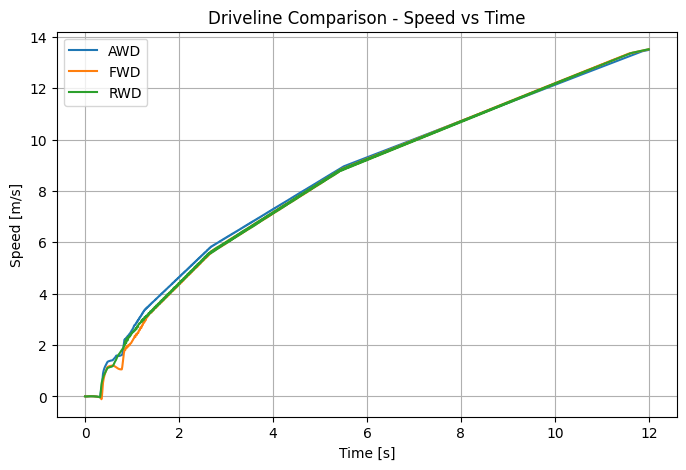

Saved figure: C:\Users\lahee\Downloads\results\phase3\driveline_comparison\figures\driveline_speed.png


In [8]:
plt.figure(figsize=(8, 5))

for driveline, df_case in df.groupby("driveline"):
    plt.plot(df_case["time"], df_case["speed"], label=driveline)

plt.xlabel("Time [s]")
plt.ylabel("Speed [m/s]")
plt.title("Driveline Comparison - Speed vs Time")
plt.grid(True)
plt.legend()

fig_path = FIGURE_DIR / "driveline_speed.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)


## 9. Acceleration Response Comparison

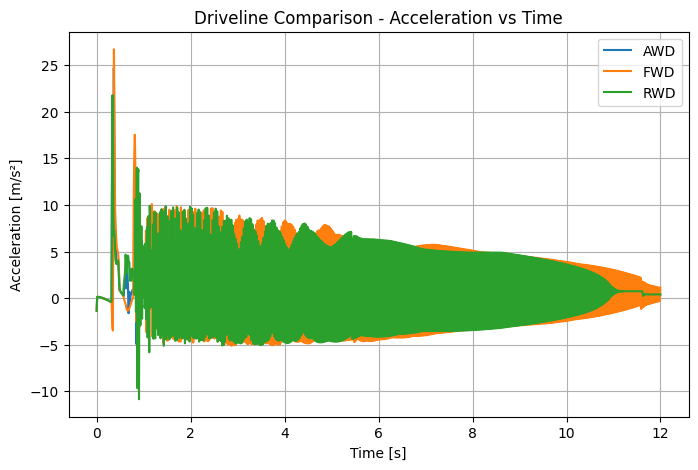

Saved figure: C:\Users\lahee\Downloads\results\phase3\driveline_comparison\figures\driveline_acceleration.png


In [9]:
plt.figure(figsize=(8, 5))

for driveline, df_case in df.groupby("driveline"):
    plt.plot(df_case["time"], df_case["acceleration"], label=driveline)

plt.xlabel("Time [s]")
plt.ylabel("Acceleration [m/s²]")
plt.title("Driveline Comparison - Acceleration vs Time")
plt.grid(True)
plt.legend()

fig_path = FIGURE_DIR / "driveline_acceleration.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)


## 10. X-Z Trajectory Comparison

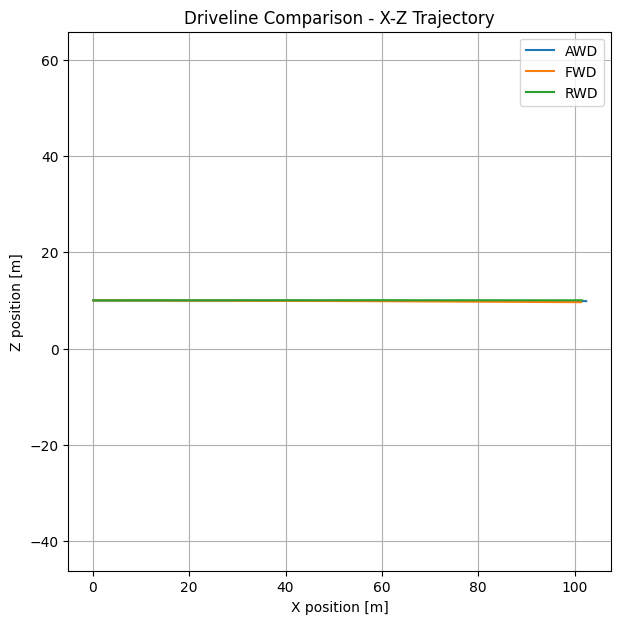

Saved figure: C:\Users\lahee\Downloads\results\phase3\driveline_comparison\figures\driveline_trajectory.png


In [10]:
plt.figure(figsize=(7, 7))

for driveline, df_case in df.groupby("driveline"):
    plt.plot(df_case["x"], df_case["z"], label=driveline)

plt.xlabel("X position [m]")
plt.ylabel("Z position [m]")
plt.title("Driveline Comparison - X-Z Trajectory")
plt.axis("equal")
plt.grid(True)
plt.legend()

fig_path = FIGURE_DIR / "driveline_trajectory.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)


## 11. Summary Metrics

In [11]:
summary_rows = []

for driveline, df_case in df.groupby("driveline"):
    travel_x = df_case["x"].iloc[-1] - df_case["x"].iloc[0]
    travel_z = df_case["z"].iloc[-1] - df_case["z"].iloc[0]
    mean_speed = df_case["speed"].mean()
    max_speed = df_case["speed"].max()
    mean_accel = df_case["acceleration"].mean()
    max_accel = df_case["acceleration"].max()

    summary_rows.append({
        "driveline": driveline,
        "travel_x_m": travel_x,
        "travel_z_m": travel_z,
        "mean_speed_mps": mean_speed,
        "max_speed_mps": max_speed,
        "mean_acceleration_mps2": mean_accel,
        "max_acceleration_mps2": max_accel,
        "fixed_steering": fixed_steering,
        "fixed_throttle": fixed_throttle,
        "terrain_friction": terrain_friction,
    })

summary_df = pd.DataFrame(summary_rows)

summary_path = RESULT_DIR / "driveline_comparison_summary.csv"
summary_df.to_csv(summary_path, index=False, encoding="utf-8-sig")

print("Saved summary:", summary_path)
display(summary_df)


Saved summary: C:\Users\lahee\Downloads\results\phase3\driveline_comparison\driveline_comparison_summary.csv


,driveline,travel_x_m,travel_z_m,mean_speed_mps,max_speed_mps,mean_acceleration_mps2,max_acceleration_mps2,fixed_steering,fixed_throttle,terrain_friction
0,AWD,102.359288,-0.143907,8.527193,13.495987,1.124544,24.674419,0.0,0.4,0.9
1,FWD,101.265064,-0.364317,8.436182,13.519370,1.126585,26.698138,0.0,0.4,0.9
2,RWD,101.482158,0.028947,8.454131,13.522675,1.126769,21.767904,0.0,0.4,0.9


## 12. Interpretation Guide

결과 해석은 다음 기준으로 하면 된다.

```text
1. AWD:
   - 네 바퀴에 구동 토크를 분배한다.
   - 험지나 저마찰 지형에서 유리할 가능성이 크다.

2. RWD:
   - 뒤쪽 axle 위주로 구동한다.
   - 가속 시 후륜 하중 증가와 연결해서 해석할 수 있다.

3. FWD:
   - 앞쪽 axle 위주로 구동한다.
   - 조향축과 구동축이 겹치므로 steering 실험과 결합하면 의미가 커진다.
```



```text
동일한 throttle 입력 조건에서도 driveline type에 따라 차량의 속도 및 가속 응답이 달라질 수 있다.
-> driveline subsystem이 powertrain 출력 토크를 어느 axle과 wheel에 분배할지 결정하기 때문이다.
-> 로버 최적 설계에서는 2WD/4WD/AWD 선택과 torque distribution이 terrain mobility 성능에 직접적인 영향을 준다.
```
